# ANALISIS SENTIMEN KUALITAS LAYANAN APLIKASI MOBILE JKN MENGGUNAKAN ALGORITMA NAIVE BAYES BERBASIS DATA ULASAN GOOGLE PLAY STORE

In [ ]:
# Instalasi Library
!pip install wordcloud tabulate Sastrawi -q

# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from IPython.display import display, Markdown

# Konfigurasi Visualisasi agar rapi di GitHub
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## 📥 BAGIAN 2: PENGUMPULAN DATA ULASAN

### 🎯 Tujuan
Langkah ini bertujuan untuk memuat dataset ulasan Mobile JKN
yang telah dikumpulkan dari Google Play Store dan memahami
struktur data yang ada.

### 📋 Sumber Data
- **Platform**: Google Play Store
- **Aplikasi**: Mobile JKN (Aplikasi resmi BPJS Kesehatan)
- **Jumlah Ulasan**: 3.000 ulasan (setelah filtering)
- **Periode Pengambilan**: April - Juni 2026

### 🔍 Kolom Data
| Kolom   | Deskripsi                                      |
|---------|------------------------------------------------|
| date    | Tanggal dan waktu ulasan diberikan             |
| score   | Rating bintang (1-5) yang diberikan pengguna   |
| review  | Teks ulasan yang ditulis oleh pengguna         |

### 📊 Output
Pada bagian ini, kita akan melihat:
1. Ringkasan data (jumlah ulasan, periode, dll)
2. Contoh data ulasan
3. Distribusi rating bintang dari pengguna

Jumlah ulasan berhasil diperoleh: 3000 ulasan
Periode pengambilan data: 4/22/2026 11:08 s/d 6/5/2026 9:51
Jumlah data sebelum seleksi: ~984.000 (berdasarkan data Play Store)
Jumlah data sesudah seleksi & filtering: 3000 ulasan


Tabel Data Hasil Scraping :


,date,score,review
0,6/5/2026 14:03,1,"Daftar autodebet gagal mulu notifnya, padahal ..."
1,6/5/2026 13:40,1,perbaiki dong aplikasinya masa nomor telpon ko...
2,6/5/2026 12:23,5,aplikasi sampah. eror terus harus jaringan 10G...
3,6/5/2026 12:12,5,aplikasi bagus prosesnya cepat dan menunya len...
4,6/5/2026 11:47,5,sangat baik dan bermanfaat sangat lebih cepat ...
...,...,...,...
2995,4/22/2026 13:18,1,"KLO aplikasi tidak terpakai, harus Selalu teru..."
2996,4/22/2026 12:10,1,kenapa yaa apa2 yg berbau pemerintah bawaan ny...
2997,4/22/2026 12:07,5,"kenapa siih aplikasi ini, tiba-tiba Log out,, ..."
2998,4/22/2026 11:47,1,gile dari 2023 coba daftar sampe sekarang masi...


Tabel Distribusi Rating:


,Rating,Jumlah,Persentase
0,1,1714,57.13%
1,2,190,6.33%
2,3,141,4.7%
3,4,88,2.93%
4,5,867,28.9%


/tmp/ipykernel_1171/1593375474.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rating', y='Jumlah', data=rating_dist, palette=colors_rating)


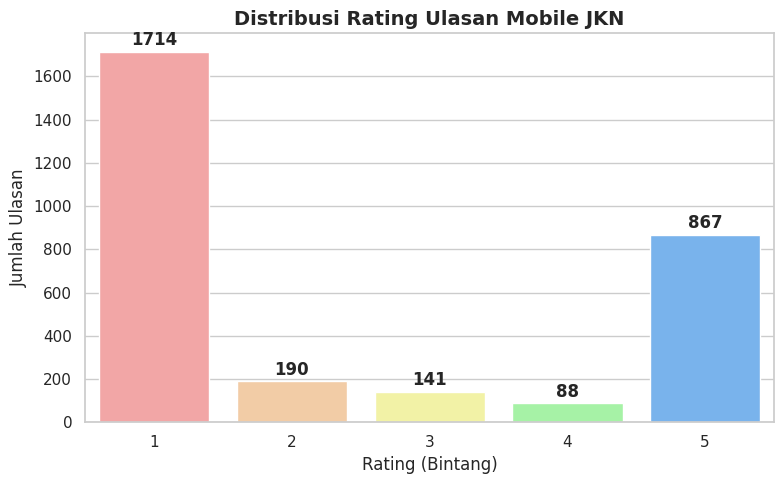

In [ ]:
# Load dataset
df = pd.read_csv('/content/ulasan_mobileJKN.csv')

# Pastikan dataframe tidak kosong
assert not df.empty, "Dataset kosong! Periksa path file Anda."

total_data = len(df)
min_date = df['date'].min()
max_date = df['date'].max()


print(f"Jumlah ulasan berhasil diperoleh: {total_data} ulasan")
print(f"Periode pengambilan data: {min_date} s/d {max_date}")
print(f"Jumlah data sebelum seleksi: ~984.000 (berdasarkan data Play Store)")
print(f"Jumlah data sesudah seleksi & filtering: {total_data} ulasan\n")

# Tabel Contoh Data
print("\nTabel Data Hasil Scraping :")
cols_to_show = ['date', 'score', 'review']
if 'label' in df.columns:
    cols_to_show.append('label')
display(df[cols_to_show].head(3000))

# Distribusi Rating
rating_dist = df['score'].value_counts().sort_index().reset_index()
rating_dist.columns = ['Rating', 'Jumlah']
rating_dist['Persentase'] = (rating_dist['Jumlah'] / total_data * 100).round(2).astype(str) + '%'

print("Tabel Distribusi Rating:")
display(rating_dist)

# Visualisasi Distribusi Rating
plt.figure(figsize=(8, 5))
colors_rating = ['#ff9999', '#ffcc99', '#ffff99', '#99ff99', '#66b3ff']
sns.barplot(x='Rating', y='Jumlah', data=rating_dist, palette=colors_rating)
plt.title('Distribusi Rating Ulasan Mobile JKN', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Ulasan')
plt.xlabel('Rating (Bintang)')
plt.xticks(ticks=range(5), labels=[1, 2, 3, 4, 5])
for i, v in enumerate(rating_dist['Jumlah']):
    plt.text(i, v + (total_data * 0.01), str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



## 🏷️ BAGIAN 3: PELABELAN SENTIMEN (LABELING)

### 🎯 Tujuan
Mengubah rating bintang (numerik) menjadi label sentimen
(kategorikal) untuk memudahkan proses klasifikasi.

### 📋 Aturan Pelabelan
| Rating Bintang | Label Sentimen     | Kategori |
|----------------|--------------------|----------|
| ⭐⭐⭐⭐⭐ (5)  | Memuaskan          | Positif  |
| ⭐⭐⭐⭐ (4)   | Memuaskan          | Positif  |
| ⭐⭐⭐ (3)     | Tidak Memuaskan    | Negatif  |
| ⭐⭐ (2)      | Tidak Memuaskan    | Negatif  |
| ⭐ (1)         | Tidak Memuaskan    | Negatif  |

### 💡 Alasan Pemilihan Threshold
- Rating **4-5 bintang** dianggap **positif** karena pengguna
  memberikan penilaian baik terhadap aplikasi.
- Rating **1-3 bintang** dianggap **negatif** karena pengguna
  menyampaikan keluhan atau ketidakpuasan.

### 📊 Output
Distribusi kelas sentimen yang akan digunakan untuk:
- Training model Naive Bayes
- Evaluasi performa model).

Tabel Distribusi Kelas Sentimen:


,Kelas Sentimen,Jumlah,Persentase
0,Tidak Memuaskan,2045,68.17%
1,Memuaskan,955,31.83%


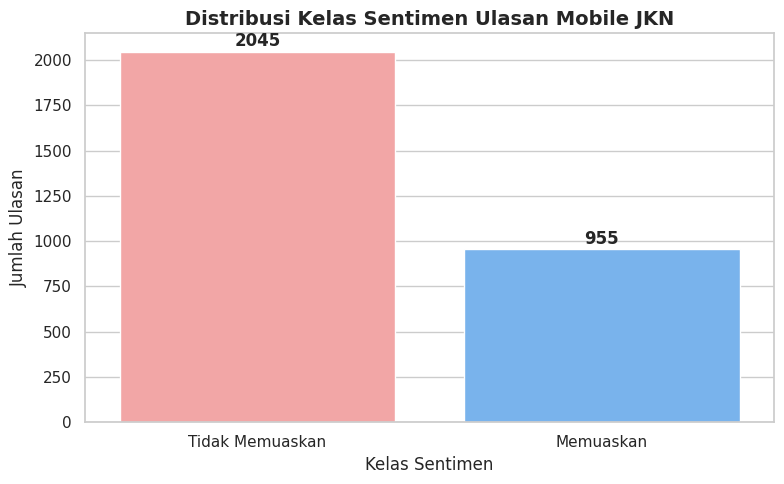

In [ ]:
# Labeling berdasarkan score
if 'label' not in df.columns:
    df['label'] = df['score'].apply(lambda x: 'Memuaskan' if x > 3 else 'Tidak Memuaskan')

# Distribusi Kelas Sentimen
dist = df['label'].value_counts().reset_index()
dist.columns = ['Kelas Sentimen', 'Jumlah']
dist['Persentase'] = (dist['Jumlah'] / total_data * 100).round(2).astype(str) + '%'

print("Tabel Distribusi Kelas Sentimen:")
display(dist)

# Visualisasi Sebaran Kelas
plt.figure(figsize=(8, 5))
sns.barplot(x='Kelas Sentimen', y='Jumlah', data=dist, palette=['#ff9999','#66b3ff'], hue='Kelas Sentimen', legend=False)
plt.title('Distribusi Kelas Sentimen Ulasan Mobile JKN', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Ulasan')
plt.xlabel('Kelas Sentimen')
for i, v in enumerate(dist['Jumlah']):
    plt.text(i, v + (total_data * 0.01), str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 🧹 BAGIAN 4: PRE-PROCESSING TEKS

### 🎯 Tujuan
Membersihkan dan menstandarisasi teks ulasan agar siap
diproses oleh algoritma machine learning.

### 📋 Tahapan Pre-Processing

#### 1️⃣ Case Folding
Mengubah semua teks menjadi huruf kecil agar konsisten.
- Contoh: `"Aplikasi Bagus"` → `"aplikasi bagus"`

#### 2️⃣ Normalisasi Kata
Mengubah singkatan dan typo menjadi kata baku.
- Contoh: `"gk"` → `"tidak"`, `"bgt"` → `"banget"`

#### 3️⃣ Tokenizing
Memecah kalimat menjadi kata-kata individual (token).
- Contoh: `"aplikasi bagus"` → `["aplikasi", "bagus"]`

#### 4️⃣ Filtering (Stopword Removal)
Menghapus kata-kata umum yang tidak bermakna (seperti "yang", "dan").
- **Penting**: Kata negasi seperti "tidak", "bukan" dipertahankan
  karena penting untuk analisis sentimen.

#### 5️⃣ Stemming
Mengubah kata berimbuhan menjadi kata dasar.
- Contoh: `"membantu"` → `"bantu"`, `"diperbaiki"` → `"perbaiki"`

### 💡 Mengapa Pre-Processing Penting?
- Meningkatkan akurasi model
- Mengurangi noise dalam data
- Menstandarisasi variasi bahasa.

In [ ]:
cmap = 'Reds'

# ==========================================================
# KAMUS NORMALISASI
# ==========================================================
kamus_normalisasi = {

    # =============================================
    # 1. SINGKATAN UMUM
    # =============================================
    'yg': 'yang', 'gk': 'tidak', 'gak': 'tidak', 'nggak': 'tidak',
    'ngga': 'tidak', 'ga': 'tidak', 'tdk': 'tidak', 'g': 'tidak',
    'gx': 'tidak', 'gak': 'tidak',
    'krn': 'karena', 'krna': 'karena', 'karna': 'karena',
    'klo': 'kalau', 'kalo': 'kalau', 'klu': 'kalau',
    'utk': 'untuk', 'untk': 'untuk', 'utuk': 'untuk',
    'dgn': 'dengan', 'tp': 'tapi',
    'udh': 'sudah', 'udah': 'sudah',
    'blm': 'belum', 'lum': 'belum',
    'aja': 'saja', 'ajah': 'saja', 'doang': 'saja',
    'cma': 'cuma',
    'bkn': 'bukan', 'dr': 'dari',
    'pdhl': 'padahal', 'padhal': 'padahal',
    'thd': 'terhadap', 'thn': 'tahun', 'bln': 'bulan',
    'hr': 'hari', 'jgn': 'jangan',
    'sy': 'saya', 'sya': 'saya', 'aq': 'saya',
    'gw': 'saya', 'gue': 'saya',
    'lo': 'kamu', 'lu': 'kamu', 'km': 'kamu', 'kmu': 'kamu',
    'klian': 'kalian',
    'dpt': 'dapat', 'dapet': 'dapat',
    'bsa': 'bisa', 'bs': 'bisa',
    'gbs': 'tidak bisa', 'gabisa': 'tidak bisa', 'gkbs': 'tidak bisa',
    'gmn': 'bagaimana', 'gimana': 'bagaimana', 'bgmn': 'bagaimana',
    'knp': 'kenapa', 'kenape': 'kenapa', 'nape': 'kenapa',
    'kpn': 'kapan', 'kpan': 'kapan',
    'brp': 'berapa', 'brpa': 'berapa',
    'apaan': 'apa', 'apaa': 'apa', 'apa2': 'apa',
    'gini': 'begini', 'gitu': 'begitu', 'bgtu': 'begitu',
    'sbg': 'sebagai', 'sbagai': 'sebagai', 'sbgai': 'sebagai',
    'spy': 'supaya', 'biar': 'agar',
    'jd': 'jadi', 'skrng': 'sekarang',
    'smpe': 'sampai', 'sampe': 'sampai',
    'byr': 'bayar', 'donk': 'dong',
    'tlong': 'tolong', 'tolong': 'tolong',
    'ktanya': 'katanya', 'dftr': 'daftar',
    'bkin': 'bikin', 'bentar': 'sebentar',
    'mang': 'memang', 'mao': 'mau',
    'klu': 'kalau', 'taon': 'tahun',
    'untk': 'untuk', 'utuk': 'untuk',

    # =============================================
    # 2. TYPO KATA UMUM
    # =============================================
    'bgt': 'banget', 'bgtt': 'banget', 'bngt': 'banget',
    'bnget': 'banget', 'bgst': 'banget', 'bangett': 'banget',
    'mulu': 'melulu', 'trus': 'terus', 'teruz': 'terus',
    'bener': 'benar', 'bner': 'benar', 'bnr': 'benar',
    'salh': 'salah', 'slh': 'salah',
    'emang': 'memang', 'emg': 'memang', 'emng': 'memang',
    'ribet': 'ribet', 'ribett': 'ribet', 'ruwet': 'ribet',
    'lemot': 'lemot', 'lemott': 'lemot', 'lelet': 'lemot',
    'eror': 'error', 'erorr': 'error',
    'bapuk': 'rusak', 'bapukk': 'rusak', 'bapukkk': 'rusak',
    'bapet': 'rusak', 'bengak': 'rusak',
    'bobrok': 'rusak', 'busuk': 'rusak',
    'bgs': 'bagus', 'mantab': 'mantap', 'mantep': 'mantap',
    'mantull': 'mantap', 'markotop': 'mantap',
    'parahh': 'parah', 'parahhh': 'parah',
    'jelekk': 'jelek', 'jeleqq': 'jelek',
    'payahh': 'payah', 'payahhh': 'payah',
    'burukk': 'buruk', 'burukkk': 'buruk',
    'ampas': 'buruk', 'ampass': 'buruk',
    'sampahh': 'sampah', 'sampahhh': 'sampah',
    'cacatt': 'cacat',
    'gajelas': 'tidak jelas', 'gaje': 'tidak jelas',
    'gajeless': 'tidak jelas', 'gajelass': 'tidak jelas',
    'gakjelas': 'tidak jelas', 'nggakjelas': 'tidak jelas',
    'gaunaa': 'tidak berguna', 'gakguna': 'tidak berguna',
    'gaguna': 'tidak berguna', 'gagunaa': 'tidak berguna',
    'gauguna': 'tidak berguna',

    # =============================================
    # 3. TYPO BARU
    # =============================================
    'brobat': 'berobat', 'sdangkan': 'sedangkan',
    'tlong': 'tolong', 'ngurus': 'mengurus',
    'smpe': 'sampai', 'bgnian': 'beginian',
    'ktanya': 'katanya', 'trdftr': 'terdaftar',
    'dftr': 'daftar', 'skrng': 'sekarang',
    'jd': 'jadi', 'bkin': 'bikin',
    'mao': 'mau', 'layan': 'layanan',
    'muas': 'puas', 'yaaaa': 'ya', 'yaaa': 'ya', 'yaa': 'ya',
    'diiperbaiki': 'diperbaiki', 'lhoo': 'loh', 'lho': 'loh',
    'bentar': 'sebentar', 'rubah': 'ubah',
    'utuk': 'untuk', 'untk': 'untuk',
    'kompitable': 'kompatibel', 'kompatible': 'kompatibel',
    'gembelll': 'gembel', 'gembell': 'gembel',
    'masukin': 'masukkan', 'katain': 'dikatai',
    'benerin': 'perbaiki', 'taon': 'tahun',
    'perhati': 'perhatikan', 'dateng': 'datang',
    'singkron': 'sinkron', 'adain': 'adakan',
    'ngaco': 'ngaco', 'ngacoo': 'ngaco',
    'kedo': 'ke', 'oyp': 'otp',
    'sdh': 'sudah', 'blom': 'belum',
    'dlm': 'dalam', 'dri': 'dari',
    'kdg': 'kadang', 'kdang': 'kadang',
    'lma': 'lama', 'lm': 'lama',
    'bgni': 'begini', 'bgini': 'begini',
    'lg': 'lagi', 'lgi': 'lagi',
    'tpi': 'tapi', 'tp': 'tapi',
    'msuk': 'masuk', 'msk': 'masuk',
    'bisa2': 'bisa-bisa', 'gagal2': 'gagal-gagal',
    'susahh': 'susah', 'susahhh': 'susah',
    'lamaa': 'lama', 'lamaaa': 'lama',
    'lam': 'lama', 'lam aaa': 'lama',
    'pake': 'pakai', 'pakek': 'pakai',
    'make': 'memakai', 'makek': 'memakai',
    'pny': 'punya', 'puny': 'punya',
    'nomer': 'nomor', 'nomor': 'nomor',
    'bener': 'benar', 'benerin': 'perbaiki',
    'beneran': 'benar', 'bener2': 'benar-benar',
    'benerin': 'perbaiki',
    'gangu': 'ganggu', 'ganggu': 'ganggu',
    'gangguan': 'gangguan', 'ganggua': 'ganggu',
    'tolol': 'bodoh', 'tololl': 'bodoh',
    'anjir': '', 'anj': '', 'njir': '',
    'bgsd': '', 'brengsek': '',
    'tai': 'buruk', 'taik': 'buruk', 'taii': 'buruk',
    'asu': 'buruk', 'asuu': 'buruk',
    'nyusahin': 'menyusahkan', 'nyulitin': 'menyulitkan',
    'ngebantu': 'membantu', 'ngebantuin': 'membantu',
    'nunggu': 'menunggu', 'nunggu2': 'menunggu',
    'nunggu²': 'menunggu', 'nungu': 'menunggu',
    'ngetik': 'mengetik', 'ngetiknya': 'mengetik',
    'nulis': 'menulis', 'nbaca': 'membaca',
    'nyoba': 'mencoba', 'nyari': 'mencari',
    'nyuruh': 'menyuruh', 'nyampe': 'sampai',
    'nyala': 'menyala', 'nangis': 'menangis',
    'dipake': 'dipakai', 'dipakek': 'dipakai',
    'dimasukin': 'dimasukkan', 'dikatain': 'dikatai',
    'dibenerin': 'diperbaiki', 'diperbaikin': 'diperbaiki',
    'didaftarin': 'didaftarkan',
    'kejadian': 'kejadian', 'kejadiannya': 'kejadian',
    'seharus': 'seharusnya', 'seharusn': 'seharusnya',
    'sempet': 'sempat', 'sempat': 'sempat',
    'ampe': 'sampai', 'sampek': 'sampai',
    'kayak': 'seperti', 'kaya': 'seperti',
    'kayaknya': 'sepertinya', 'kayak': 'seperti',
    'gitu2': 'begitu-begitu', 'gini2': 'begini-begini',
    'sering2': 'sering-sering', 'kadang2': 'kadang-kadang',
    'hati2': 'hati-hati', 'baik2': 'baik-baik',
    'terus2': 'terus-terus', 'terus2an': 'terus-terusan',
    'tiba2': 'tiba-tiba', 'tiba²': 'tiba-tiba',
    'tibatiba': 'tiba-tiba',
    'kali2': 'berkali-kali', 'berkali2': 'berkali-kali',
    'lagi2': 'lagi-lagi', 'lagi²': 'lagi-lagi',
    'gagal2': 'gagal-gagal', 'gagal²': 'gagal-gagal',
    'berkali2': 'berkali-kali', 'berkali²': 'berkali-kali',
    'smpai': 'sampai', 'smp': 'sampai',
    'ngirim': 'mengirim', 'ngirim2': 'mengirim',
    'dikirim2': 'dikirim', 'dikirm': 'dikirim',
    'kirim2': 'kirim', 'ngirimnya': 'mengirim',
    'gampang': 'mudah', 'gampangg': 'mudah',
    'susah': 'sulit', 'susahh': 'sulit',
    'susahhh': 'sulit', 'susa': 'sulit',
    'bantu': 'bantu', 'bantuan': 'bantuan',
    'bntu': 'bantu', 'bnatu': 'bantu',
    'terbantu': 'terbantu', 'terbatu': 'terbantu',
    'mmbantu': 'membantu', 'membatu': 'membantu',
    'mempermuadh': 'mempermudah', 'mempermudh': 'mempermudah',
    'mempersulit': 'mempersulit', 'mempersult': 'mempersulit',
    'mempermudah': 'mempermudah', 'mempermuda': 'mempermudah',
    'di permudah': 'dipermudah', 'di persulit': 'dipersulit',
    'di perbaiki': 'diperbaiki', 'di perbaikin': 'diperbaiki',
    'diperbaik': 'diperbaiki', 'diperbiki': 'diperbaiki',
    'diperbaikin': 'diperbaiki', 'diprbaiki': 'diperbaiki',
    'diperbaikk': 'diperbaiki', 'dperbaiki': 'diperbaiki',
    'di benerin': 'diperbaiki', 'dibenerin': 'diperbaiki',

    # =============================================
    # 4. ISTILAH APLIKASI & TEKNOLOGI
    # =============================================
    'apk': 'apk', 'ap': 'apk', 'app': 'apk', 'apps': 'apk',
    'aplikasinya': 'aplikasi', 'aplikas': 'aplikasi',
    'aplkasi': 'aplikasi', 'aplikais': 'aplikasi',
    'login': 'login', 'log': 'login', 'loging': 'login',
    'loggin': 'login', 'loginn': 'login', 'loginnya': 'login',
    'log in': 'login', 'login in': 'login',
    'logout': 'logout', 'logut': 'logout', 'logot': 'logout',
    'logaut': 'logout', 'log out': 'logout',
    'login out': 'logout', 'loginout': 'logout',
    'password': 'password', 'pasword': 'password',
    'paswrod': 'password', 'paswotd': 'password',
    'passwordnya': 'password', 'paswordnya': 'password',
    'paswod': 'password', 'passwrod': 'password',
    'sandi': 'password',
    'pin': 'pin', 'pinnya': 'pin',
    'captcha': 'captcha', 'capcha': 'captcha',
    'capcay': 'captcha', 'captca': 'captcha',
    'capthca': 'captcha', 'captha': 'captcha',
    'catcha': 'captcha', 'gatcha': 'captcha',
    'capctha': 'captcha', 'kapcha': 'captcha',
    'otp': 'otp', 'oyp': 'otp', 'opt': 'otp', 'otpnya': 'otp',
    'sms': 'sms', 'email': 'email', 'gmail': 'gmail',
    'wa': 'whatsapp', 'whatsap': 'whatsapp',
    'watsapp': 'whatsapp', 'whtsapp': 'whatsapp',
    'whatsappnya': 'whatsapp',
    'verif': 'verifikasi', 'verivikasi': 'verifikasi',
    'verifkasi': 'verifikasi', 'verifikasi': 'verifikasi',
    'vermuk': 'verifikasi', 'verifwajah': 'verifikasi',
    'verifmuka': 'verifikasi', 'verifface': 'verifikasi',
    'terverivikasi': 'terverifikasi', 'terverifkasi': 'terverifikasi',
    'trverifikasi': 'terverifikasi', 'terverifikasi': 'terverifikasi',
    'scan': 'scan', 'scanning': 'scan',
    'skrining': 'skrining', 'screening': 'skrining',
    'skrening': 'skrining', 'skring': 'skrining',
    'update': 'update', 'updet': 'update', 'updaate': 'update',
    'upgrade': 'update', 'upgred': 'update', 'upgread': 'update',
    'diupdate': 'update', 'di update': 'update',
    'download': 'download', 'downlod': 'download',
    'dowload': 'download', 'dowloand': 'download',
    'donlod': 'download', 'donload': 'download',
    'instal': 'install', 'insttal': 'install', 'istal': 'install',
    'unistal': 'uninstall', 'uninstal': 'uninstall',
    'crash': 'crash', 'ngebug': 'bug',
    'bug': 'bug', 'bugg': 'bug', 'buggg': 'bug', 'bagg': 'bug',
    'loading': 'loading', 'loding': 'loading', 'loadding': 'loading',
    'load': 'loading',
    'screenshot': 'screenshot', 'ss': 'screenshot',
    'capture': 'screenshot',
    'notifikasi': 'notifikasi', 'notif': 'notifikasi',
    'notip': 'notifikasi', 'notifikasi': 'notifikasi',
    'signal': 'sinyal', 'sinyal': 'sinyal', 'sinyall': 'sinyal',
    'koneksi': 'koneksi', 'koneks': 'koneksi',
    'jaringan': 'jaringan', 'jaringn': 'jaringan',
    'server': 'server', 'servernya': 'server',
    'akun': 'akun', 'akunya': 'akun', 'akunn': 'akun',
    'data': 'data', 'datanya': 'data',
    'fitur': 'fitur', 'fiturnya': 'fitur',
    'menu': 'menu', 'tampilan': 'tampilan',
    'kamera': 'kamera', 'kameranya': 'kamera',
    'layar': 'layar', 'memory': 'memori',
    'memori': 'memori', 'memorry': 'memori',
    'gawai': 'gawai', 'gawainya': 'gawai',
    'hp': 'hp', 'hape': 'hp', 'handphone': 'hp',
    'ponsel': 'hp', 'smartphone': 'hp',
    'perangkat': 'perangkat', 'device': 'perangkat',
    'android': 'android', 'ios': 'ios',
    'iphone': 'iphone', 'samsung': 'samsung',
    'wifi': 'wifi', 'internet': 'internet',
    'pulsa': 'pulsa', 'kuota': 'kuota',
    'online': 'online', 'offline': 'offline',

    # =============================================
    # 5. ISTILAH BPJS & KESEHATAN
    # =============================================
    'bpjs': 'bpjs', 'jkn': 'jkn', 'mjkn': 'jkn',
    'mobilejkn': 'mobile jkn',
    'faskes': 'faskes', 'faskes1': 'faskes',
    'fktp': 'faskes', 'fkrtl': 'faskes',
    'fasilitas': 'fasilitas', 'fasilitass': 'fasilitas',
    'puskesmas': 'puskesmas', 'pkm': 'puskesmas',
    'puskemas': 'puskesmas', 'puskesma': 'puskesmas',
    'klinik': 'klinik', 'klnik': 'klinik',
    'rs': 'rumah sakit', 'rumahsakit': 'rumah sakit',
    'rsud': 'rumah sakit', 'rsup': 'rumah sakit',
    'igd': 'igd', 'poli': 'poli', 'poliklinik': 'poli',
    'dokter': 'dokter', 'dr': 'dokter',
    'perawat': 'perawat', 'obat': 'obat',
    'resep': 'resep', 'rujukan': 'rujukan',
    'rujuk': 'rujukan', 'merujuk': 'rujukan',
    'dirujuk': 'rujukan', 'periksa': 'periksa',
    'berobat': 'berobat', 'kontrol': 'kontrol',
    'pemeriksaan': 'pemeriksaan', 'perawatan': 'perawatan',
    'pengobatan': 'pengobatan',
    'rawat inap': 'rawat inap', 'rawat jalan': 'rawat jalan',
    'opname': 'rawat inap', 'operasi': 'operasi',
    'antrian': 'antrian', 'antrean': 'antrian',
    'antri': 'antrian', 'antre': 'antrian',
    'daftar': 'daftar', 'pendaftaran': 'pendaftaran',
    'mendaftar': 'daftar', 'terdaftar': 'terdaftar',
    'trdftr': 'terdaftar', 'dftr': 'daftar',
    'registrasi': 'registrasi', 'regist': 'registrasi',
    'regristasi': 'registrasi', 'regristrasi': 'registrasi',
    'tagihan': 'tagihan', 'iuran': 'iuran',
    'bayar': 'bayar', 'pembayaran': 'pembayaran',
    'tunggakan': 'tunggakan', 'denda': 'denda',
    'autodebet': 'autodebet', 'auto debit': 'autodebet',
    'auto debet': 'autodebet',
    'va': 'va', 'qris': 'qris',
    'mbanking': 'mbanking', 'mobile banking': 'mbanking',
    'atm': 'atm', 'kartu': 'kartu',
    'ktp': 'ktp', 'ektp': 'ktp', 'e-ktp': 'ktp',
    'kk': 'kk', 'nik': 'nik', 'npwp': 'npwp',
    'kemenkes': 'kemenkes', 'kemendagri': 'kemendagri',
    'dukcapil': 'dukcapil', 'kemensos': 'kemensos',
    'cs': 'cs', 'admin': 'admin',
    'customer service': 'cs', 'call center': 'cs',
    'callcenter': 'cs', 'pandawa': 'pandawa',
    'peserta': 'peserta', 'pasien': 'pasien',
    'anggota': 'anggota', 'keluarga': 'keluarga',
    'masyarakat': 'masyarakat', 'rakyat': 'rakyat',
    'warga': 'warga', 'lansia': 'lansia',
    'orangtua': 'orang tua', 'ortu': 'orang tua',
    'pengguna': 'pengguna', 'user': 'pengguna',

    # =============================================
    # 6. KATA SIFAT & EMOSI
    # =============================================
    'puas': 'puas', 'puass': 'puas', 'puasss': 'puas',
    'muas': 'puas', 'memuaskan': 'puas',
    'suka': 'suka', 'sukaa': 'suka',
    'senang': 'senang', 'bahagia': 'bahagia',
    'terima kasih': 'terima kasih', 'terimakasih': 'terima kasih',
    'trimakasih': 'terima kasih', 'makasih': 'terima kasih',
    'tq': 'terima kasih', 'thx': 'terima kasih',
    'thanks': 'terima kasih',
    'marah': 'marah', 'kesal': 'kesal',
    'kesell': 'kesal', 'kesel': 'kesal',
    'sebell': 'kesal', 'sebel': 'kesal',
    'emosi': 'marah', 'emosii': 'marah',
    'gedeg': 'marah',
    'kecewa': 'kecewa', 'kecewaa': 'kecewa', 'kecewaaa': 'kecewa',
    'sedih': 'sedih', 'sedihh': 'sedih',
    'frustasi': 'frustrasi',
    'stres': 'stres', 'stress': 'stres', 'stresss': 'stres',
    'pusing': 'pusing', 'pusingg': 'pusing',
    'puyeng': 'pusing', 'mumet': 'pusing', 'mumett': 'pusing',
    'sakit': 'sakit', 'sehat': 'sehat', 'sembuh': 'sembuh',
    'penting': 'penting', 'cepat': 'cepat',
    'lambat': 'lambat', 'lama': 'lama', 'lma': 'lama',
    'segera': 'segera', 'tunggu': 'tunggu',
    'menunggu': 'menunggu', 'nunggu': 'menunggu',
    'ditunggu': 'ditunggu',
    'kirim': 'kirim', 'dikirim': 'dikirim',
    'terkirim': 'terkirim', 'ngirim': 'mengirim',
    'masuk': 'masuk', 'msuk': 'masuk', 'msk': 'masuk',
    'keluar': 'keluar', 'buka': 'buka', 'tutup': 'tutup',
    'pakai': 'pakai', 'pake': 'pakai', 'pakek': 'pakai',
    'guna': 'guna', 'berguna': 'berguna',
    'manfaat': 'manfaat', 'bermanfaat': 'bermanfaat',
    'membantu': 'membantu', 'bantu': 'bantu',
    'mempermudah': 'mempermudah', 'mempersulit': 'mempersulit',
    'menyulitkan': 'menyulitkan', 'menyusahkan': 'menyusahkan',
    'memudahkan': 'memudahkan',
    'bikin': 'buat', 'buat': 'buat', 'jadi': 'jadi',
    'masalah': 'masalah', 'kendala': 'kendala',
    'hambatan': 'hambatan', 'gangguan': 'gangguan',
    'gagal': 'gagal', 'sukses': 'sukses', 'berhasil': 'berhasil',
    'aktif': 'aktif', 'nonaktif': 'nonaktif',
    'sesuai': 'sesuai', 'tidak sesuai': 'tidak sesuai',
    'cocok': 'cocok', 'benar': 'benar', 'salah': 'salah',
    'bagus': 'bagus', 'buruk': 'buruk',
    'parah': 'parah', 'payah': 'payah', 'jelek': 'jelek',
    'sampah': 'sampah', 'cacat': 'cacat', 'rusak': 'rusak',
    'mantap': 'mantap', 'jos': 'bagus', 'joss': 'bagus',
    'ribet': 'ribet',
    'sangat': 'sangat', 'banget': 'banget',
    'sekali': 'sekali', 'paling': 'paling',
    'lebih': 'lebih', 'kurang': 'kurang',
    'cukup': 'cukup', 'lumayan': 'lumayan',
    'agak': 'agak', 'sedikit': 'sedikit',
    'banyak': 'banyak', 'semua': 'semua',
    'setiap': 'setiap', 'tiap': 'tiap',
    'sering': 'sering', 'selalu': 'selalu',
    'kadang': 'kadang', 'kdg': 'kadang', 'kdang': 'kadang',
    'jarang': 'jarang', 'terus': 'terus',
    'lagi': 'lagi', 'lg': 'lagi', 'lgi': 'lagi',
    'kembali': 'kembali', 'sudah': 'sudah',
    'belum': 'belum', 'akan': 'akan', 'sedang': 'sedang',
    'harus': 'harus', 'wajib': 'wajib', 'perlu': 'perlu',
    'butuh': 'butuh', 'mau': 'mau', 'ingin': 'ingin',
    'pengen': 'ingin', 'bisa': 'bisa',
    'tidak': 'tidak', 'bukan': 'bukan',
    'jangan': 'jangan', 'dengan': 'dengan',
    'untuk': 'untuk', 'dari': 'dari', 'dari': 'dari',
    'dan': 'dan', 'atau': 'atau', 'yang': 'yang',
    'ini': 'ini', 'itu': 'itu', 'saya': 'saya',
    'kamu': 'kamu', 'mereka': 'mereka',
    'kami': 'kami', 'kita': 'kita', 'anehhh': 'aneh',
    'dajjal':'dajal', 'dahh': 'dah',

    # =============================================
    # 7. KATA-KATA YANG SERING MENEMPEL
    # =============================================
    'dipersulitudh': 'dipersulit sudah',
    'dipersulitudah': 'dipersulit sudah',
    'sayasya': 'saya saya',
    'trdftrpas': 'terdaftar pas',
    'trdftrpdhl': 'terdaftar padahal',
    'lmatp': 'lama tapi',
    'bgnitolong': 'begini tolong',
    'sistemnyajgn': 'sistemnya jangan',
    'tinggalmenyesuaikan': 'tinggal menyesuaikan',
    'ribetterimakasih': 'ribet terima kasih',
    'prosedurnyajgn': 'prosedurnya jangan',
    'bekerjadenganhati': 'bekerja dengan hati',
    'kemensosyang': 'kemensos yang',
    'tnipolriasnanggota': 'tni polri asn anggota',
    'dewanpadahal': 'dewan padahal',
    'masuklagunya': 'masuk lagunya',
    'ngacocngaco': 'ngaco ngaco',
    'keluar2': 'keluar-keluar',
    'masuk2': 'masuk-masuk',
    'gagal2': 'gagal-gagal',
    'error2': 'error-error',
    'keluar²': 'keluar-keluar',
    'masuk²': 'masuk-masuk',
    'gagal²': 'gagal-gagal',
    'bolakbalik': 'bolak balik',
    'mutermuter': 'muter muter',
    'kosonngkn': 'kosongkan',
    'kosongkn': 'kosongkan',
    'kosongin': 'kosongkan',
    'diadain': 'diadakan',
    'di adain': 'diadakan',
    'diperlambatkan': 'diperlambat',
    'memperlambat': 'memperlambat',
}
# ==========================================================
# PRE-PROCESSING TEKS (DIPERBAIKI)
# ==========================================================

factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

KATA_NEGASI = ['tidak', 'bukan', 'jangan', 'belum', 'kurang', 'enggak', 'tak', 'bukanlah']
reviews_all = df['review'].astype(str).tolist()

def normalisasi_kata(text, kamus):
    words = text.split()
    normalized = [kamus.get(word, word) for word in words]
    # Hapus kata kosong (hasil normalisasi kata yang dihapus seperti 'wkwk' → '')
    normalized = [w for w in normalized if w.strip() != '']
    return ' '.join(normalized)

# ==========================================================
# PERBAIKAN PENTING: Ganti tanda baca dengan SPASI, bukan hapus
# Ini mencegah kata menempel seperti "dipersulit,udah" → "dipersulitudh"
# ==========================================================

# 1. Case Folding (PERBAIKAN: tanda baca → spasi)
cf_results_all = []
for r in reviews_all:
    temp = r.lower()
    # Ganti tanda baca & simbol dengan spasi (bukan dihapus)
    temp = re.sub(r'[^a-z0-9\s]', ' ', temp)
    # Hapus spasi berlebih
    temp = re.sub(r'\s+', ' ', temp).strip()
    cf_results_all.append(temp)
df['cf_text'] = cf_results_all

# 2. Normalisasi Kata
norm_results_all = [normalisasi_kata(text, kamus_normalisasi) for text in df['cf_text']]
df['norm_text'] = norm_results_all

# 3. Tokenizing
df['tokenized_text'] = [r.split() for r in df['norm_text']]

# 4. Filtering
filt_results_all = []
for tokens in df['tokenized_text']:
    filtered = [word for word in tokens if stopword.remove(word) != '' or word in KATA_NEGASI]
    filt_results_all.append(filtered)
df['filtered_text'] = filt_results_all

# 5. Stemming
stem_results_all = [[stemmer.stem(word) for word in tokens] for tokens in df['filtered_text']]
df['stemmed_text'] = stem_results_all

# Final Clean Text
df['clean_text'] = df['stemmed_text'].apply(lambda x: ' '.join(x))

print(f"✅ Pre-processing selesai untuk {len(df)} ulasan")
print(f"   Tahapan: Case Folding → Normalisasi → Tokenizing → Filtering → Stemming")
# ==========================================================
# TAMPILKAN TABEL PRE-PROCESSING
# ==========================================================

sample_df = df[df['review'].str.len() > 50].head(5)
if len(sample_df) < 5:
    sample_df = df.head(5)

df_preprocessing = pd.DataFrame({
    'No': [i + 1 for i in range(len(sample_df))],
    'Review Asli': sample_df['review'].astype(str).tolist(),
    'Case Folding': sample_df['cf_text'].astype(str).tolist(),
    'Normalisasi': sample_df['norm_text'].astype(str).tolist(),
    'Tokenizing': sample_df['tokenized_text'].apply(str).tolist(),
    'Filtering': sample_df['filtered_text'].apply(str).tolist(),
    'Stemming': sample_df['stemmed_text'].apply(str).tolist()
})

styled_table = df_preprocessing.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'vertical-align': 'top',
    'padding': '10px',
    'border': '1px solid #333333',
    'background-color': '#000000',
    'color': 'white'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#4472C4'),
        ('color', 'white'),
        ('font-weight', 'bold'),
        ('text-align', 'center'),
        ('padding', '10px'),
        ('border', '1px solid #2F5597')
    ]},
    {'selector': 'td', 'props': [
        ('border', '1px solid #333333'),
        ('background-color', '#000000'),
        ('color', 'white')
    ]},
    {'selector': 'tr:nth-child(even)', 'props': [
        ('background-color', '#1a1a1a'),
        ('color', 'white')
    ]}
])

print("📋 Tabel Contoh Proses Pre-Processing Teks (dengan Normalisasi)")
display(styled_table)


✅ Pre-processing selesai untuk 3000 ulasan
   Tahapan: Case Folding → Normalisasi → Tokenizing → Filtering → Stemming
📋 Tabel Contoh Proses Pre-Processing Teks (dengan Normalisasi)


,No,Review Asli,Case Folding,Normalisasi,Tokenizing,Filtering,Stemming
0,1,"Daftar autodebet gagal mulu notifnya, padahal notif sms dari bca berhasil. ini beneran bug atau emang akal-akal oknum bpjs yang kaya dajjal bin maruk duit?",daftar autodebet gagal mulu notifnya padahal notif sms dari bca berhasil ini beneran bug atau emang akal akal oknum bpjs yang kaya dajjal bin maruk duit,daftar autodebet gagal melulu notifnya padahal notifikasi sms dari bca berhasil ini benar bug atau memang akal akal oknum bpjs yang seperti dajal bin maruk duit,"['daftar', 'autodebet', 'gagal', 'melulu', 'notifnya', 'padahal', 'notifikasi', 'sms', 'dari', 'bca', 'berhasil', 'ini', 'benar', 'bug', 'atau', 'memang', 'akal', 'akal', 'oknum', 'bpjs', 'yang', 'seperti', 'dajal', 'bin', 'maruk', 'duit']","['daftar', 'autodebet', 'gagal', 'melulu', 'notifnya', 'padahal', 'notifikasi', 'sms', 'bca', 'berhasil', 'benar', 'bug', 'memang', 'akal', 'akal', 'oknum', 'bpjs', 'dajal', 'bin', 'maruk', 'duit']","['daftar', 'autodebet', 'gagal', 'melulu', 'notifnya', 'padahal', 'notifikasi', 'sms', 'bca', 'hasil', 'benar', 'bug', 'memang', 'akal', 'akal', 'oknum', 'bpjs', 'dajal', 'bin', 'maruk', 'duit']"
1,2,"perbaiki dong aplikasinya masa nomor telpon kode otp nya ga masuk masuk, padahal kuota lancar pakek wifi lancar, nomornya udah benar, penyimpanan masih banyak, masa ga di kasih. anehhh banget bikin kesal",perbaiki dong aplikasinya masa nomor telpon kode otp nya ga masuk masuk padahal kuota lancar pakek wifi lancar nomornya udah benar penyimpanan masih banyak masa ga di kasih anehhh banget bikin kesal,perbaiki dong aplikasi masa nomor telpon kode otp nya tidak masuk masuk padahal kuota lancar pakai wifi lancar nomornya sudah benar penyimpanan masih banyak masa tidak di kasih aneh banget buat kesal,"['perbaiki', 'dong', 'aplikasi', 'masa', 'nomor', 'telpon', 'kode', 'otp', 'nya', 'tidak', 'masuk', 'masuk', 'padahal', 'kuota', 'lancar', 'pakai', 'wifi', 'lancar', 'nomornya', 'sudah', 'benar', 'penyimpanan', 'masih', 'banyak', 'masa', 'tidak', 'di', 'kasih', 'aneh', 'banget', 'buat', 'kesal']","['perbaiki', 'dong', 'aplikasi', 'masa', 'nomor', 'telpon', 'kode', 'otp', 'nya', 'tidak', 'masuk', 'masuk', 'padahal', 'kuota', 'lancar', 'pakai', 'wifi', 'lancar', 'nomornya', 'benar', 'penyimpanan', 'banyak', 'masa', 'tidak', 'kasih', 'aneh', 'banget', 'buat', 'kesal']","['baik', 'dong', 'aplikasi', 'masa', 'nomor', 'telpon', 'kode', 'otp', 'nya', 'tidak', 'masuk', 'masuk', 'padahal', 'kuota', 'lancar', 'pakai', 'wifi', 'lancar', 'nomor', 'benar', 'simpan', 'banyak', 'masa', 'tidak', 'kasih', 'aneh', 'banget', 'buat', 'kesal']"
2,3,aplikasi sampah. eror terus harus jaringan 10G baru bisa konek.. aneh sungguh aneh...!!!,aplikasi sampah eror terus harus jaringan 10g baru bisa konek aneh sungguh aneh,aplikasi sampah error terus harus jaringan 10g baru bisa konek aneh sungguh aneh,"['aplikasi', 'sampah', 'error', 'terus', 'harus', 'jaringan', '10g', 'baru', 'bisa', 'konek', 'aneh', 'sungguh', 'aneh']","['aplikasi', 'sampah', 'error', 'terus', 'jaringan', '10g', 'baru', 'konek', 'aneh', 'sungguh', 'aneh']","['aplikasi', 'sampah', 'error', 'terus', 'jaring', '10g', 'baru', 'konek', 'aneh', 'sungguh', 'aneh']"
3,4,sangat baik dan bermanfaat sangat lebih cepat pokoknya mantap dahh,sangat baik dan bermanfaat sangat lebih cepat pokoknya mantap dahh,sangat baik dan bermanfaat sangat lebih cepat pokoknya mantap dah,"['sangat', 'baik', 'dan', 'bermanfaat', 'sangat', 'lebih', 'cepat', 'pokoknya', 'mantap', 'dah']","['sangat', 'baik', 'bermanfaat', 'sangat', 'lebih', 'cepat', 'pokoknya', 'mantap', 'dah']","['sangat', 'baik', 'manfaat', 'sangat', 'lebih', 'cepat', 'pokok', 'mantap', 'dah']"
4,5,aplikasi terbaik.. sangat membantu jika ada perubahan apa apa lewat online gampang.. mantap,aplikasi terbaik sangat membantu jika ada perubahan apa apa lewat online gampang mantap,aplikasi terbaik sangat membantu jika ada perubahan apa apa lewat online mudah mantap,"['aplikasi', 'terbaik', 'sang

## 💾 BAGIAN 5: MENYIMPAN HASIL PRE-PROCESSING

### 🎯 Tujuan
Menyimpan DataFrame yang sudah diproses ke dalam file CSV
untuk keperluan backup atau analisis lebih lanjut.

### 📁 File Output
- **Nama File**: `ulasan_mobileJKN_preprocessed.csv`
- **Kolom yang Disimpan**:
  - `review_id`: ID ulasan
  - `review`: Teks ulasan asli
  - `clean_text`: Teks hasil pre-processing
  - `label`: Label sentimen (Memuaskan/Tidak Memuaskan)

In [ ]:
# Menyimpan DataFrame yang sudah diproses ke file CSV
output_filename = 'ulasan_mobileJKN_preprocessed.csv'

# Pilih kolom-kolom yang ingin disimpan
# Misalnya, review asli, clean_text, dan label sentimen
df_output = df[['review_id', 'review', 'clean_text', 'label']].copy()

df_output.to_csv(output_filename, index=False)

print(f"File '{output_filename}' berhasil disimpan dan siap untuk diunduh.")

# Kode untuk mengunduh file di Google Colab
from google.colab import files
files.download(output_filename)

File 'ulasan_mobileJKN_preprocessed.csv' berhasil disimpan dan siap untuk diunduh.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📊 BAGIAN 6: EKSTRAKSI FITUR TF-IDF

### 🎯 Tujuan
Mengubah teks menjadi representasi numerik menggunakan metode
**TF-IDF (Term Frequency - Inverse Document Frequency)**.

### 📖 Penjelasan TF-IDF
TF-IDF adalah teknik weighting yang memberikan skor pada setiap
kata berdasarkan:

1. **TF (Term Frequency)**: Seberapa sering kata muncul dalam
   satu dokumen.
2. **IDF (Inverse Document Frequency)**: Seberapa unik kata
   tersebut di seluruh dokumen.

**Formula**: `TF-IDF = TF × IDF`

### 💡 Mengapa TF-IDF?
- Kata yang sering muncul tapi tidak unik (seperti "yang")
  akan mendapat skor rendah.
- Kata yang jarang tapi bermakna (seperti "error", "ribet")
  akan mendapat skor tinggi.
- Cocok untuk analisis sentimen karena menekankan kata-kata
  yang membedakan opini.

### 📊 Parameter yang Digunakan
- `max_features = 5000`: Membatasi 5000 kata dengan bobot
  tertinggi untuk efisiensi komputasi.

### 📈 Output
- Top 20 kata dengan bobot TF-IDF tertinggi (keseluruhan)
- Top 10 kata per kelas sentimen (Memuaskan vs Tidak Memuaskan)

In [ ]:
# ==========================================================
# TOP 20 KATA DENGAN BOBOT TF-IDF TERTINGGI (KESELURUHAN)
# ==========================================================

# Inisialisasi dan fit TfidfVectorizer untuk seluruh data
tfidf = TfidfVectorizer(max_features=5000)
tfidf.fit(df['clean_text'])

# Transform SEMUA data ke TF-IDF
tfidf_all_matrix = tfidf.transform(df['clean_text'])
tfidf_all_array = tfidf_all_matrix.toarray()
feature_names = tfidf.get_feature_names_out()

# Hitung rata-rata bobot TF-IDF untuk setiap kata di seluruh dataset
mean_tfidf_all = tfidf_all_array.mean(axis=0);

# Ambil TOP 20 kata dengan bobot tertinggi
top_20_indices = mean_tfidf_all.argsort()[::-1][:20]

# Buat DataFrame
df_top_20 = pd.DataFrame({
    'Rank': [i + 1 for i in range(20)],
    'Kata': [feature_names[i] for i in top_20_indices],
    'Rata-rata Bobot TF-IDF': [f"{mean_tfidf_all[i]:.4f}" for i in top_20_indices]
})

# Styling Dark Theme
styled_top_20 = df_top_20.style.set_properties(**{
    'text-align': 'center',
    'vertical-align': 'middle',
    'padding': '10px',
    'background-color': '#1a1a1a',
    'color': 'white',
    'border': '1px solid #333333',
    'font-size': '12px'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#4472C4'),
        ('color', 'white'),
        ('font-weight', 'bold'),
        ('text-align', 'center'),
        ('padding', '12px 10px'),
        ('border', '1px solid #2F5597'),
        ('font-size', '12px')
    ]},
    {'selector': 'td', 'props': [
        ('border', '1px solid #333333')
    ]},
    {'selector': 'tr:nth-child(even) td', 'props': [
        ('background-color', '#0d0d0d')
    ]},
    {'selector': 'td:nth-child(2)', 'props': [
        ('text-align', 'left'),
        ('font-weight', 'bold'),
        ('color', '#66b3ff')
    ]}
])

print("📊 Tabel 20 Kata dengan Bobot TF-IDF Tertinggi (Keseluruhan Data)")
print("💡 Kata-kata ini paling sering muncul dan paling membedakan antar dokumen")
display(styled_top_20)


📊 Tabel 20 Kata dengan Bobot TF-IDF Tertinggi (Keseluruhan Data)
💡 Kata-kata ini paling sering muncul dan paling membedakan antar dokumen


,Rank,Kata,Rata-rata Bobot TF-IDF
0,1,tidak,0.0702
1,2,aplikasi,0.0583
2,3,daftar,0.0424
3,4,sulit,0.0404
4,5,mau,0.0377
5,6,masuk,0.0368
6,7,sangat,0.0350
7,8,mudah,0.0327
8,9,nya,0.0323
9,10,bantu,0.0290


### 📊 Analisis TF-IDF per Kelas Sentimen

Perbandingan kata-kata dominan yang membedakan ulasan
**Memuaskan** dan **Tidak Memuaskan**.

In [ ]:
# ==========================================================
# TOP 10 KATA TF-IDF PER KELAS SENTIMEN
# ==========================================================

# Pisahkan data berdasarkan label
df_memuaskan = df[df['label'] == 'Memuaskan']
df_tidak_memuaskan = df[df['label'] == 'Tidak Memuaskan']

# Transform per kelas
tfidf_memuaskan = tfidf.transform(df_memuaskan['clean_text']).toarray()
tfidf_tidak = tfidf.transform(df_tidak_memuaskan['clean_text']).toarray()

# Hitung rata-rata bobot per kelas
mean_tfidf_memuaskan = tfidf_memuaskan.mean(axis=0)
mean_tfidf_tidak = tfidf_tidak.mean(axis=0)

# Ambil TOP 10 kata per kelas
top_10_memuaskan_idx = mean_tfidf_memuaskan.argsort()[::-1][:10]
top_10_tidak_idx = mean_tfidf_tidak.argsort()[::-1][:10]

# Buat DataFrame perbandingan
df_perbandingan = pd.DataFrame({
    'Rank': [i + 1 for i in range(10)],
    'Kata (Memuaskan)': [feature_names[i] for i in top_10_memuaskan_idx],
    'Bobot (Memuaskan)': [f"{mean_tfidf_memuaskan[i]:.4f}" for i in top_10_memuaskan_idx],
    'Kata (Tidak Memuaskan)': [feature_names[i] for i in top_10_tidak_idx],
    'Bobot (Tidak Memuaskan)': [f"{mean_tfidf_tidak[i]:.4f}" for i in top_10_tidak_idx]
})

# Fungsi styling untuk kolom bobot
def highlight_bobot_memuaskan(val):
    try:
        v = float(val)
        if v >= 0.5:
            return 'background-color: #0066cc; color: white'
        elif v >= 0.3:
            return 'background-color: #004c99; color: white'
        elif v >= 0.15:
            return 'background-color: #003366; color: #b8daff'
        else:
            return 'background-color: #001a33; color: #66b3ff'
    except:
        return 'background-color: #1a1a1a; color: white'

def highlight_bobot_tidak(val):
    try:
        v = float(val)
        if v >= 0.5:
            return 'background-color: #cc0000; color: white'
        elif v >= 0.3:
            return 'background-color: #990000; color: white'
        elif v >= 0.15:
            return 'background-color: #660000; color: #ffb3b3'
        else:
            return 'background-color: #330000; color: #ff9999'
    except:
        return 'background-color: #1a1a1a; color: white'

styled_perbandingan = df_perbandingan.style.set_properties(**{
    'text-align': 'center',
    'vertical-align': 'middle',
    'padding': '10px',
    'background-color': '#1a1a1a',
    'color': 'white',
    'border': '1px solid #333333',
    'font-size': '12px'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#4472C4'),
        ('color', 'white'),
        ('font-weight', 'bold'),
        ('text-align', 'center'),
        ('padding', '12px 10px'),
        ('border', '1px solid #2F5597'),
        ('font-size', '12px')
    ]},
    {'selector': 'td', 'props': [
        ('border', '1px solid #333333')
    ]},
    {'selector': 'tr:nth-child(even) td', 'props': [
        ('background-color', '#0d0d0d')
    ]},
    {'selector': 'td:nth-child(2)', 'props': [
        ('text-align', 'left'),
        ('font-weight', 'bold'),
        ('color', '#66ff66')  # Hijau untuk kata memuaskan
    ]},
    {'selector': 'td:nth-child(4)', 'props': [
        ('text-align', 'left'),
        ('font-weight', 'bold'),
        ('color', '#ff6666')  # Merah untuk kata tidak memuaskan
    ]}
]).map(
    highlight_bobot_memuaskan,
    subset=['Bobot (Memuaskan)']
).map(
    highlight_bobot_tidak,
    subset=['Bobot (Tidak Memuaskan)']
)

print("📊 Tabel Perbandingan 10 Kata Penting per Kelas Sentimen")
print("💡 Kiri = Kata dominan di ulasan MEMUASKAN | Kanan = Kata dominan di ulasan TIDAK MEMUASKAN")
display(styled_perbandingan)

📊 Tabel Perbandingan 10 Kata Penting per Kelas Sentimen
💡 Kiri = Kata dominan di ulasan MEMUASKAN | Kanan = Kata dominan di ulasan TIDAK MEMUASKAN


,Rank,Kata (Memuaskan),Bobot (Memuaskan),Kata (Tidak Memuaskan),Bobot (Tidak Memuaskan)
0,1,sangat,0.0889,tidak,0.0874
1,2,bantu,0.0796,aplikasi,0.0636
2,3,mudah,0.0717,sulit,0.0506
3,4,aplikasi,0.0469,daftar,0.0493
4,5,jkn,0.0428,mau,0.0479
5,6,kasih,0.0426,masuk,0.0469
6,7,layan,0.0414,login,0.0367
7,8,terima,0.0411,nya,0.0354
8,9,bagus,0.0340,buat,0.0334
9,10,tidak,0.0332,otp,0.0330


### 📈 Visualisasi Top Kata TF-IDF

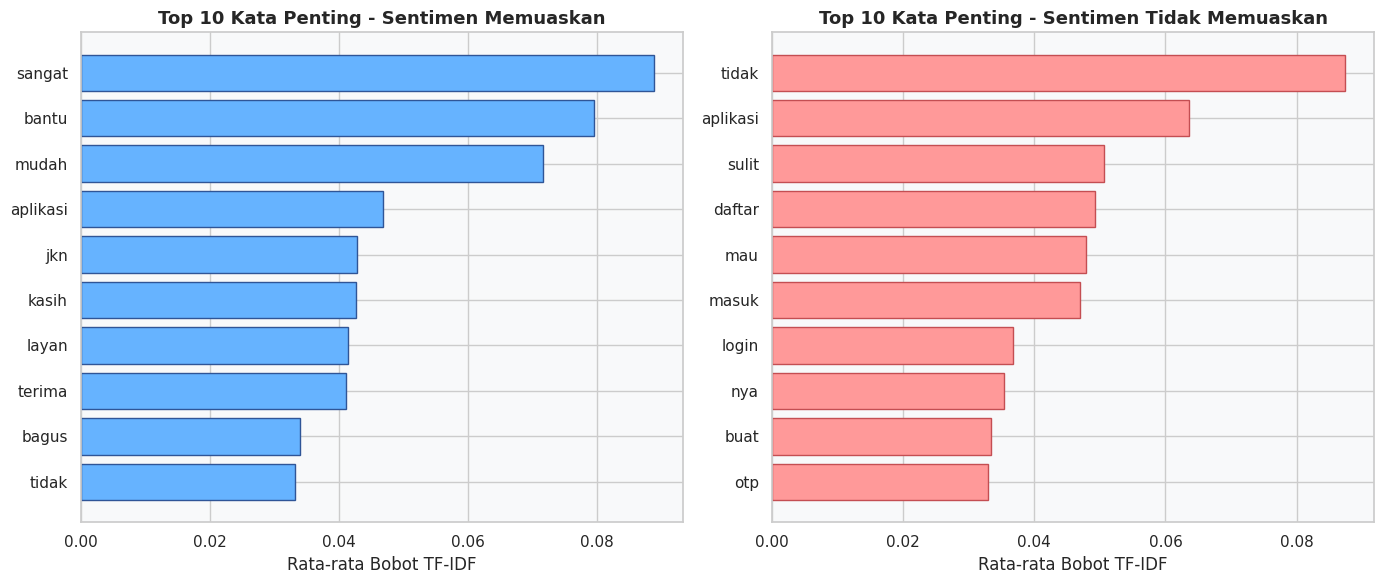


💡 INSIGHT TF-IDF:
→ Kata-kata yang paling membedakan ulasan MEMUASKAN: sangat, bantu, mudah, aplikasi, jkn
→ Kata-kata yang paling membedakan ulasan TIDAK MEMUASKAN: tidak, aplikasi, sulit, daftar, mau
→ Kata-kata ini memiliki bobot TF-IDF tinggi karena sering muncul di satu kelas tetapi jarang di kelas lain.


In [ ]:
# ==========================================================
# VISUALISASI TOP KATA TF-IDF SECARA KESELURUHAN
# ==========================================================

# Hitung rata-rata bobot TF-IDF untuk SEMUA data per kelas
tfidf_all = tfidf.transform(df['clean_text']).toarray()

# Rata-rata untuk kelas Memuaskan
df_pos = df[df['label'] == 'Memuasan'] if 'Memuasan' in df['label'].values else df[df['label'] == 'Memuaskan']
df_neg = df[df['label'] == 'Tidak Memuaskan']

tfidf_pos = tfidf.transform(df_pos['clean_text']).toarray().mean(axis=0)
tfidf_neg = tfidf.transform(df_neg['clean_text']).toarray().mean(axis=0)

# Ambil top 10 kata per kelas
top_pos_idx = tfidf_pos.argsort()[::-1][:10]
top_neg_idx = tfidf_neg.argsort()[::-1][:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Sentimen Memuaskan
words_pos = [feature_names[i] for i in top_pos_idx]
scores_pos = [tfidf_pos[i] for i in top_pos_idx]
axes[0].barh(words_pos[::-1], scores_pos[::-1], color='#66b3ff', edgecolor='#2F5597')
axes[0].set_title('Top 10 Kata Penting - Sentimen Memuaskan', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rata-rata Bobot TF-IDF')
axes[0].set_facecolor('#f8f9fa')

# Plot Sentimen Tidak Memuaskan
words_neg = [feature_names[i] for i in top_neg_idx]
scores_neg = [tfidf_neg[i] for i in top_neg_idx]
axes[1].barh(words_neg[::-1], scores_neg[::-1], color='#ff9999', edgecolor='#c44e52')
axes[1].set_title('Top 10 Kata Penting - Sentimen Tidak Memuaskan', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rata-rata Bobot TF-IDF')
axes[1].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

# Tampilkan insight
print("\n💡 INSIGHT TF-IDF:")
print(f"→ Kata-kata yang paling membedakan ulasan MEMUASKAN: {', '.join(words_pos[:5])}")
print(f"→ Kata-kata yang paling membedakan ulasan TIDAK MEMUASKAN: {', '.join(words_neg[:5])}")
print("→ Kata-kata ini memiliki bobot TF-IDF tinggi karena sering muncul di satu kelas tetapi jarang di kelas lain.")

## 🔍 BAGIAN 7: ANALISIS BERDASARKAN FITUR LAYANAN

### 🎯 Tujuan
Memetakan keluhan pengguna ke dalam fitur-fitur spesifik
aplikasi Mobile JKN untuk mengidentifikasi area yang perlu
diperbaiki.

### 📋 Fitur Layanan yang Dianalisis

| No | Fitur Layanan          | Deskripsi                              |
|----|------------------------|----------------------------------------|
| 1  | Autentikasi Pengguna   | Login, OTP, verifikasi, password       |
| 2  | Antrean Online         | Booking, pendaftaran, jadwal           |
| 3  | Perubahan FKTP         | Pindah faskes, rujukan                 |
| 4  | Informasi Kepesertaan  | Data peserta, iuran, tagihan           |
| 5  | Stabilitas Sistem      | Error, bug, loading, crash             |

### 📊 Output
- Distribusi sentimen per fitur layanan
- Persentase keluhan per fitur
- Rekomendasi prioritas perbaikan

DISTRIBUSI SENTIMEN BERDASARKAN FITUR LAYANAN


label,Memuaskan,Tidak Memuaskan,Total,Persentase Memuaskan (%),Persentase Tidak Memuaskan (%)
fitur,,,,,
Autentikasi Pengguna,171,1058,1229,13.91,86.09
Antrean Online,172,652,824,20.87,79.13
Stabilitas Sistem,76,591,667,11.39,88.61
Informasi Kepesertaan,138,273,411,33.58,66.42
Perubahan FKTP,90,89,179,50.28,49.72


<Figure size 1200x600 with 0 Axes>

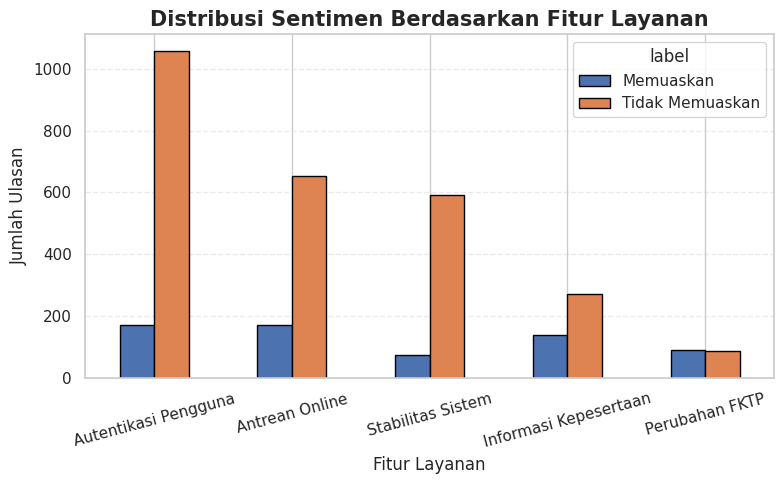



INTERPRETASI HASIL


------------------------------------------------------------------------------------------
Fitur : Autentikasi Pengguna
Memuaskan : 171
Tidak Memuaskan : 1058

Fitur Autentikasi Pengguna didominasi sentimen TIDAK MEMUASKAN (86.09%). Hal ini menunjukkan bahwa pengguna masih banyak menyampaikan keluhan terhadap layanan tersebut sehingga diperlukan perbaikan untuk meningkatkan kualitas layanan Mobile JKN.


------------------------------------------------------------------------------------------
Fitur : Antrean Online
Memuaskan : 172
Tidak Memuaskan : 652

Fitur Antrean Online didominasi sentimen TIDAK MEMUASKAN (79.13%). Hal ini menunjukkan bahwa pengguna masih banyak menyampaikan keluhan terhadap layanan tersebut sehingga diperlukan perbaikan untuk meningkatkan kualitas layanan Mobile JKN.


------------------------------------------------------------------------------------------
Fitur : Stabilitas Sistem
Memuaskan : 76
Tidak Memuaskan : 591

Fitur Stabilitas Si

In [ ]:
# ==========================================================
# ANALISIS BERDASARKAN FITUR LAYANAN MOBILE JKN
# ==========================================================

analisis = df.copy()

fitur_layanan = {

    "Autentikasi Pengguna": [
        "login",
        "otp",
        "verifikasi",
        "password",
        "akun",
        "captcha",
        "kode"
    ],

    "Antrean Online": [
        "antrian",
        "antrean",
        "nomor antrian",
        "booking",
        "daftar",
        "jadwal"
    ],

    "Perubahan FKTP": [
        "fasilitas kesehatan",
        "fktp",
        "faskes",
        "rujuk",
        "rujukan",
        "pindah"
    ],

    "Informasi Kepesertaan": [
        "peserta",
        "kepesertaan",
        "kartu",
        "bpjs",
        "nik",
        "kelas",
        "iuran",
        "bayar",
        "autodebet"
    ],

    "Stabilitas Sistem": [
        "error",
        "bug",
        "loading",
        "gagal",
        "lambat",
        "lemot",
        "crash",
        "force close",
        "notifikasi",
        "sms",
        "wifi"
    ]

}

def identifikasi_fitur(text):

    text = str(text).lower()
    hasil = []
    for fitur, keywords in fitur_layanan.items():
        for kata in keywords:
            if re.search(r"\b"+re.escape(kata)+r"\b", text):
                hasil.append(fitur)
                break
    return hasil

analisis["fitur"] = analisis["clean_text"].apply(identifikasi_fitur)
analisis = analisis[analisis["fitur"].str.len()>0]
analisis = analisis.explode("fitur")
tabel = pd.crosstab(
    analisis["fitur"],
    analisis["label"]
)
if "Memuaskan" not in tabel.columns:
    tabel["Memuaskan"]=0
if "Tidak Memuaskan" not in tabel.columns:
    tabel["Tidak Memuaskan"]=0
tabel=tabel[["Memuaskan","Tidak Memuaskan"]]
tabel["Total"]=tabel.sum(axis=1)
tabel["Persentase Memuaskan (%)"]=round(
    tabel["Memuaskan"]/tabel["Total"]*100,
    2
)

tabel["Persentase Tidak Memuaskan (%)"]=round(
    tabel["Tidak Memuaskan"]/tabel["Total"]*100,
    2
)
tabel=tabel.sort_values(
    by="Total",
    ascending=False
)

print("="*90)
print("DISTRIBUSI SENTIMEN BERDASARKAN FITUR LAYANAN")
print("="*90)
display(tabel)
plt.figure(figsize=(12,6))
tabel[["Memuaskan","Tidak Memuaskan"]].plot(
    kind="bar",
    edgecolor="black"
)
plt.title(
    "Distribusi Sentimen Berdasarkan Fitur Layanan",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Fitur Layanan")
plt.ylabel("Jumlah Ulasan")
plt.xticks(rotation=15)
plt.grid(axis="y",linestyle="--",alpha=0.4)
plt.tight_layout()
plt.show()

print("\n")
print("="*90)
print("INTERPRETASI HASIL")
print("="*90)
for fitur in tabel.index:
    puas=tabel.loc[fitur,"Memuaskan"]
    tidak=tabel.loc[fitur,"Tidak Memuaskan"]
    persen_puas=tabel.loc[fitur,"Persentase Memuaskan (%)"]
    persen_tidak=tabel.loc[fitur,"Persentase Tidak Memuaskan (%)"]
    print("\n")
    print("-"*90)
    print("Fitur :",fitur)
    print("Memuaskan :",puas)
    print("Tidak Memuaskan :",tidak)
    print()
    if tidak>puas:
        print(f"Fitur {fitur} didominasi sentimen TIDAK MEMUASKAN ({persen_tidak}%). Hal ini menunjukkan bahwa pengguna masih banyak menyampaikan keluhan terhadap layanan tersebut sehingga diperlukan perbaikan untuk meningkatkan kualitas layanan Mobile JKN.")
    elif puas>tidak:
        print(f"Fitur {fitur} didominasi sentimen MEMUASKAN ({persen_puas}%). Hal ini menunjukkan bahwa sebagian besar pengguna memberikan tanggapan positif terhadap kualitas layanan pada fitur tersebut.")
    else:
        print("Jumlah sentimen memuaskan dan tidak memuaskan relatif seimbang.")
# ==========================================================
# SIMPAN HASIL
# ==========================================================

tabel.to_excel(

    "Analisis_Fitur_Layanan_Mobile_JKN.xlsx"

)

print("\nFile berhasil disimpan : Analisis_Fitur_Layanan_Mobile_JKN.xlsx")

## 🤖 BAGIAN 8: TRAINING MODEL NAIVE BAYES

### 🎯 Tujuan
Membangun dan melatih model **Multinomial Naive Bayes** untuk
mengklasifikasikan sentimen ulasan secara otomatis.

### 📖 Apa itu Naive Bayes?
Naive Bayes adalah algoritma klasifikasi berbasis **Teorema Bayes**
dengan asumsi "naive" bahwa setiap fitur saling independen.


### 📋 Mengapa Multinomial Naive Bayes?
- Cocok untuk data teks (word count)
- Cepat dan efisien secara komputasi
- Bekerja baik dengan data berdimensi tinggi
- Cocok untuk analisis sentimen

### 📊 Data Split
- **Training Set**: 80% (2.400 ulasan)
- **Testing Set**: 20% (600 ulasan)
- **Stratify**: Mempertahankan proporsi kelas

### 📈 Output
- Tabel hasil klasifikasi
- Distribusi prediksi
- Contoh data yang salah diklasifikasi

In [ ]:
# ==========================================================
# MEMBUAT DATA HASIL KLASIFIKASI
# ==========================================================

hasil_klasifikasi = pd.DataFrame({
    "Ulasan": X_test.reset_index(drop=True),
    "Label Aktual": y_test.reset_index(drop=True),
    "Label Prediksi": pd.Series(y_pred)
})
hasil_klasifikasi.insert(
    0,
    "No",
    range(1, len(hasil_klasifikasi)+1)
)

print("="*90)
print("HASIL KLASIFIKASI MULTINOMIAL NAIVE BAYES")
print("="*90)
display(
    hasil_klasifikasi.head(20)
)

# ==========================================================
# DISTRIBUSI HASIL PREDIKSI
# ==========================================================
print("\n")
print("="*90)
print("DISTRIBUSI HASIL PREDIKSI")
print("="*90)
distribusi = (
    hasil_klasifikasi["Label Prediksi"]
    .value_counts()
    .rename_axis("Kategori Sentimen")
    .reset_index(name="Jumlah")
)
distribusi["Persentase (%)"] = round(
    distribusi["Jumlah"]
    / distribusi["Jumlah"].sum()
    *100,
    2
)
display(distribusi)
# ==========================================================
# CEK HASIL PREDIKSI YANG BENAR
# ==========================================================
hasil_klasifikasi["Status Prediksi"] = np.where(
    hasil_klasifikasi["Label Aktual"] == hasil_klasifikasi["Label Prediksi"],
    "Benar",
    "Salah"
)
print("\n")
print("="*90)
print("JUMLAH PREDIKSI")
print("="*90)
print(
    hasil_klasifikasi["Status Prediksi"]
    .value_counts()
)
# ==========================================================
# MENAMPILKAN DATA YANG SALAH DIPREDIKSI
# ==========================================================
print("\n")
print("="*90)
print("CONTOH DATA YANG SALAH DIKLASIFIKASIKAN")
print("="*90)
display(
    hasil_klasifikasi
    [
        hasil_klasifikasi["Status Prediksi"]=="Salah"
    ]
    .head(15)
)

# ==========================================================
# SIMPAN KE EXCEL
# ==========================================================

hasil_klasifikasi.to_excel(

    "Hasil_Klasifikasi_Multinomial_Naive_Bayes.xlsx",

    index=False

)

print("\n")

print("File berhasil disimpan : Hasil_Klasifikasi_Multinomial_Naive_Bayes.xlsx")

HASIL KLASIFIKASI MULTINOMIAL NAIVE BAYES


,No,Ulasan,Label Aktual,Label Prediksi
0,1,meski antri lama alhamdulilah manfaat orang keci,Memuaskan,Memuaskan
1,2,apk tidak jelas mau daftar tidak apk rusak,Tidak Memuaskan,Tidak Memuaskan
2,3,sangat mudah guna bantu masyarakat umum,Memuaskan,Memuaskan
3,4,buat aplikasi anak sd mula sih sebenernya buka...,Tidak Memuaskan,Tidak Memuaskan
4,5,kok mau daftar error terus kak,Tidak Memuaskan,Tidak Memuaskan
5,6,verifikasi bekal kali coba percumah tidak tida...,Memuaskan,Tidak Memuaskan
6,7,apk macam apa mau klik menu muncul notifikasi ...,Tidak Memuaskan,Tidak Memuaskan
7,8,rubah lokasi faskes 1 sangat mudah lalu jkn mo...,Memuaskan,Memuaskan
8,9,sulit sekali login bagaimana daftar jangkau la...,Tidak Memuaskan,Tidak Memuaskan
9,10,baik dong sistem otp nya masa kirim otp sulit,Tidak Memuaskan,Tidak Memuaskan




DISTRIBUSI HASIL PREDIKSI


,Kategori Sentimen,Jumlah,Persentase (%)
0,Tidak Memuaskan,491,81.83
1,Memuaskan,109,18.17




JUMLAH PREDIKSI
Status Prediksi
Benar    506
Salah     94
Name: count, dtype: int64


CONTOH DATA YANG SALAH DIKLASIFIKASIKAN


,No,Ulasan,Label Aktual,Label Prediksi,Status Prediksi
5,6,verifikasi bekal kali coba percumah tidak tida...,Memuaskan,Tidak Memuaskan,Salah
14,15,makan nih bintang akun jadi pas ambil no antri...,Memuaskan,Tidak Memuaskan,Salah
26,27,ribet daftar hapus fitur senyum lah masa senyu...,Memuaskan,Tidak Memuaskan,Salah
33,34,senang bantu jkn,Tidak Memuaskan,Memuaskan,Salah
35,36,dear mobile jkn kapan baik sistem nya selesai,Memuaskan,Tidak Memuaskan,Salah
46,47,baca baca bacaa sulit mau login in pertama log...,Memuaskan,Tidak Memuaskan,Salah
54,55,kali buka fitur faskes tingkat pertama selalu ...,Memuaskan,Tidak Memuaskan,Salah
55,56,aplikasi tidak jelas isi data bolak balik maca...,Memuaskan,Tidak Memuaskan,Salah
59,60,baca aku mau verifikasi kode otp tidak kartu p...,Memuaskan,Tidak Memuaskan,Salah
60,61,masuk akun cepat sekarang langsung,Memuaskan,Tidak Memuaskan,Salah




File berhasil disimpan : Hasil_Klasifikasi_Multinomial_Naive_Bayes.xlsx


## 📈 BAGIAN 9: EVALUASI PERFORMA MODEL

### 🎯 Tujuan
Mengukur performa model Naive Bayes menggunakan metrik
evaluasi standar machine learning.

Hasil Confusion Matrix:
TN: 403 | FP: 6 | FN: 88 | TP: 103



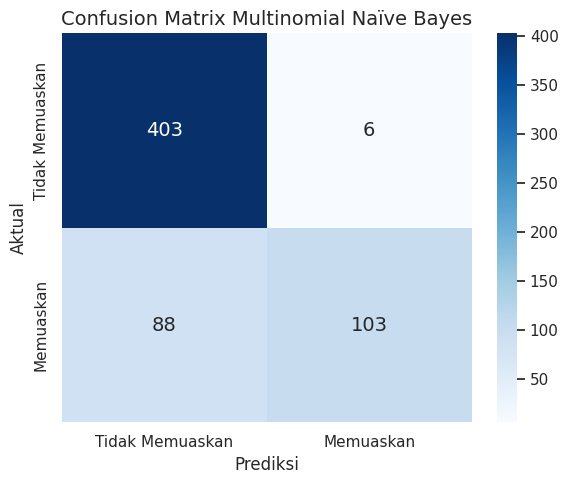

Hasil Pengukuran Metrik Evaluasi:
1. Accuracy  : 0.8433 (84.33%)
2. Precision : 0.8603 (86.03%)
3. Recall    : 0.8433 (84.33%)
4. F1-Score  : 0.8291 (82.91%)


In [ ]:
# Data Splitting & TF-IDF
X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Training & Prediksi
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)
y_pred = model_nb.predict(X_test_tfidf)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Tidak Memuaskan', 'Memuaskan'])
tn, fp, fn, tp = cm.ravel()
print("Hasil Confusion Matrix:")
print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}\n")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Memuaskan', 'Memuaskan'], yticklabels=['Tidak Memuaskan', 'Memuaskan'], annot_kws={"size": 14})
plt.ylabel('Aktual', fontsize=12); plt.xlabel('Prediksi', fontsize=12)
plt.title('Confusion Matrix Multinomial Naïve Bayes', fontsize=14)
plt.tight_layout()
plt.show()

# Metrik Evaluasi
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Hasil Pengukuran Metrik Evaluasi:")
print(f"1. Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"2. Precision : {prec:.4f} ({prec*100:.2f}%)")
print(f"3. Recall    : {rec:.4f} ({rec*100:.2f}%)")
print(f"4. F1-Score  : {f1:.4f} ({f1*100:.2f}%)")

In [ ]:
interpretasi_md = f"""
> **Interpretasi Metrik Evaluasi:**
> - **Accuracy** sebesar **{acc*100:.2f}%** menunjukkan tingkat ketepatan keseluruhan model.
> - **Precision** **{prec*100:.2f}%** menunjukkan dari semua ulasan yang diprediksi sebagai suatu kelas, persentase tersebut benar.
> - **Recall** **{rec*100:.2f}%** menunjukkan kemampuan model dalam menemukan semua data yang sebenarnya termasuk dalam kelas tersebut.
> - **F1-Score** **{f1*100:.2f}%** menunjukkan keseimbangan yang baik antara Precision dan Recall.
"""
display(Markdown(interpretasi_md))


> **Interpretasi Metrik Evaluasi:**
> - **Accuracy** sebesar **84.33%** menunjukkan tingkat ketepatan keseluruhan model.
> - **Precision** **86.03%** menunjukkan dari semua ulasan yang diprediksi sebagai suatu kelas, persentase tersebut benar.
> - **Recall** **84.33%** menunjukkan kemampuan model dalam menemukan semua data yang sebenarnya termasuk dalam kelas tersebut.
> - **F1-Score** **82.91%** menunjukkan keseimbangan yang baik antara Precision dan Recall.


## 📊 BAGIAN 10: ANALISIS DIMENSI E-SERVQUAL

### 🎯 Tujuan
Memetakan keluhan pengguna ke dalam dimensi **E-ServQual**
untuk analisis kualitas layanan elektronik yang lebih mendalam.

### 📖 Apa itu E-ServQual?
E-ServQual adalah framework untuk mengukur kualitas layanan
elektronik yang terdiri dari 5 dimensi:

| No | Dimensi             | Deskripsi                                      |
|----|---------------------|------------------------------------------------|
| 1  | **Efficiency**      | Kemudahan dan kecepatan penggunaan sistem      |
| 2  | **Fulfillment**     | Kemampuan sistem memenuhi janji layanan        |
| 3  | **System Availability** | Ketersediaan dan kestabilan sistem         |
| 4  | **Privacy**         | Keamanan dan privasi data pengguna             |
| 5  | **Usability**       | Kemudahan penggunaan antarmuka                 |

### 📋 Kata Kunci per Dimensi
- **Efficiency**: cepat, lambat, lemot, sulit, mudah, praktis
- **Fulfillment**: gagal, sukses, fitur, manfaat, bantu
- **System Availability**: error, bug, down, offline, server
- **Privacy**: data, pribadi, aman, bocor, password
- **Usability**: navigasi, ribet, membingungkan, menu, tampilan

### 📊 Output
- Ranking dimensi berdasarkan jumlah keluhan
- Kata dominan per dimensi
- Rekomendasi perbaikan prioritas

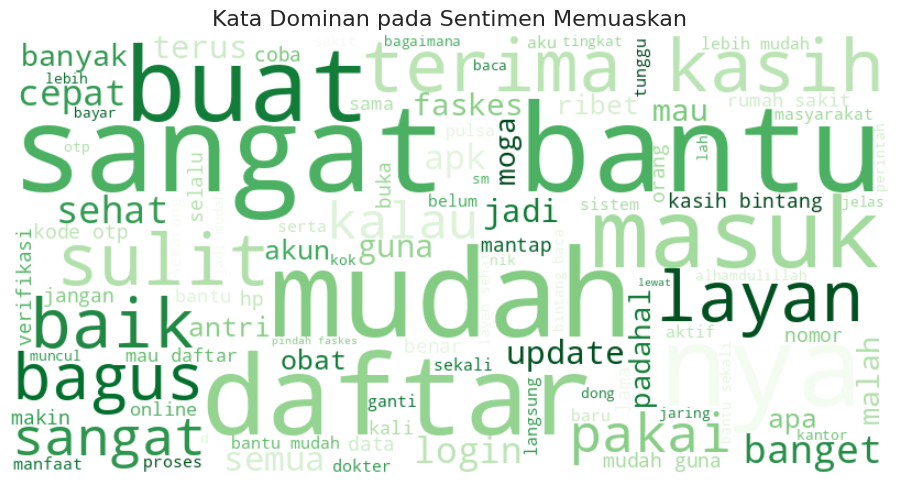

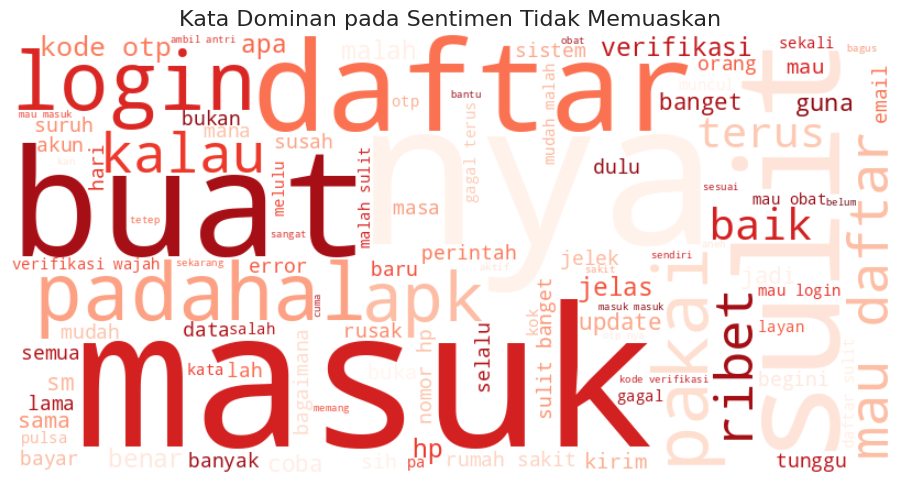

Tabel Pemetaan Dimensi E-ServQual (Berdasarkan Ulasan Negatif):


,Dimensi E-ServQual,Kata Kunci,Total Penyebutan,Kata Dominan
0,Efficiency,"cepat, lambat, lemot, sulit, mudah, praktis, antre, antri",993,sulit (621x)
3,Privacy,"data, pribadi, aman, bocor, password, sand, nik, nomor",528,nomor (221x)
1,Fulfillment,"gagal, sukses, fitur, manfaat, bantu, guna, sesuai, rujuk",485,gagal (176x)
2,System Availability,"error, bug, down, offline, server, gangguan, macet, keluar, logout",423,error (174x)
4,Usability,"mudah dipahami, navigasi, ribet, membingungkan, menu, tampilan, antarmuka, susah dipahami, user friendly",282,ribet (274x)


In [ ]:
# Gabungkan teks untuk Word Cloud
text_positif = " ".join(review for review in df[df['label'] == 'Memuaskan']['clean_text'])
text_negatif = " ".join(review for review in df[df['label'] == 'Tidak Memuaskan']['clean_text'])

# PERBAIKAN BUG: set.update() mengembalikan None, harus dipisah
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['aplikasi', 'mobile', 'jkn', 'bpjs', 'saya', 'yang', 'dan', 'di', 'ke', 'untuk', 'dengan', 'ini', 'itu', 'ada', 'juga', 'bisa', 'tidak'])

# Word Cloud
for label, text, cmap, title in [('Memuaskan', text_positif, 'Greens', 'Sentimen Memuaskan'),
                                 ('Tidak Memuaskan', text_negatif, 'Reds', 'Sentimen Tidak Memuaskan')]:
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap=cmap, stopwords=custom_stopwords).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'Kata Dominan pada {title}', fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Pemetaan E-ServQual
dimensi_keywords = {
    'Efficiency': ['cepat', 'lambat', 'lemot', 'sulit', 'mudah', 'praktis', 'antre', 'antri'],
    'Fulfillment': ['gagal', 'sukses', 'fitur', 'manfaat', 'bantu', 'guna', 'sesuai', 'rujuk'],
    'System Availability': ['error', 'bug', 'down', 'offline', 'server', 'gangguan', 'macet', 'keluar', 'logout'],
    'Privacy': ['data', 'pribadi', 'aman', 'bocor', 'password', 'sand', 'nik', 'nomor'],
    'Usability': ['mudah dipahami', 'navigasi', 'ribet', 'membingungkan', 'menu', 'tampilan', 'antarmuka', 'susah dipahami', 'user friendly']
}

hasil_pemetaan = []
for dimensi, keywords in dimensi_keywords.items():
    total_kejadian, kata_terbanyak, max_count = 0, "", 0
    for kw in keywords:
        count = df[df['label'] == 'Tidak Memuaskan']['clean_text'].str.contains(rf'\b{kw}\b', case=False, na=False).sum()
        total_kejadian += count
        if count > max_count: max_count, kata_terbanyak = count, kw

    hasil_pemetaan.append({
        'Dimensi E-ServQual': dimensi, 'Kata Kunci': ', '.join(keywords),
        'Total Penyebutan': total_kejadian, 'Kata Dominan': f"{kata_terbanyak} ({max_count}x)"
    })

df_dimensi = pd.DataFrame(hasil_pemetaan).sort_values(by='Total Penyebutan', ascending=False)
print("Tabel Pemetaan Dimensi E-ServQual (Berdasarkan Ulasan Negatif):")
display(df_dimensi.style.set_properties(**{'text-align': 'left'}))

In [ ]:
dimensi_teratas = df_dimensi.iloc[0]['Dimensi E-ServQual']

analisis_md = f"""
> **Analisis dan Rekomendasi:**
> 1. Berdasarkan tabel di atas, dimensi yang paling banyak memperoleh keluhan adalah **{dimensi_teratas}**.
> 2. Hal ini menunjukkan bahwa pengguna Mobile JKN paling kecewa terhadap aspek tersebut (misal: sistem yang sering error/logout atau proses yang lambat).
> 3. **Rekomendasi:** Pengembang Mobile JKN perlu memprioritaskan perbaikan pada infrastruktur server untuk mengurangi 'error' dan 'logout' mendadak, serta menyederhanakan alur registrasi agar tidak 'ribet' atau 'sulit', terutama bagi pengguna lansia.
"""
display(Markdown(analisis_md))


> **Analisis dan Rekomendasi:**
> 1. Berdasarkan tabel di atas, dimensi yang paling banyak memperoleh keluhan adalah **Efficiency**.
> 2. Hal ini menunjukkan bahwa pengguna Mobile JKN paling kecewa terhadap aspek tersebut (misal: sistem yang sering error/logout atau proses yang lambat).
> 3. **Rekomendasi:** Pengembang Mobile JKN perlu memprioritaskan perbaikan pada infrastruktur server untuk mengurangi 'error' dan 'logout' mendadak, serta menyederhanakan alur registrasi agar tidak 'ribet' atau 'sulit', terutama bagi pengguna lansia.
